In [6]:
# Importing Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
# Loading Dataset
df = pd.read_csv("creditcard.csv")
print(df['Class'].value_counts(normalize=True))


Class
0    0.998273
1    0.001727
Name: proportion, dtype: float64


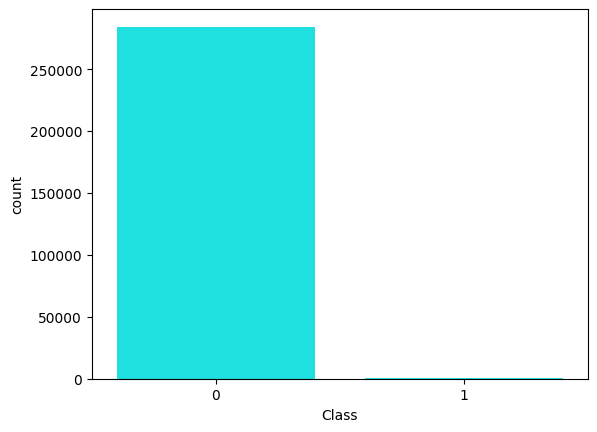

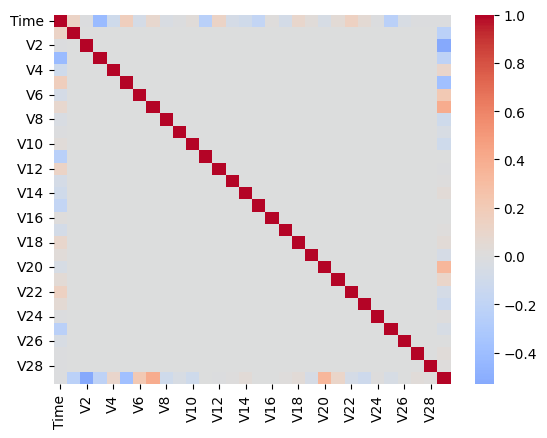

In [5]:
# Visualizing Class Distribution
sns.countplot(x='Class', data=df,color='cyan')
plt.show()

corr = df.drop(columns=['Class']).corr()
sns.heatmap(corr, cmap='coolwarm', center=0)
plt.show()

In [14]:
# Logistic Regression Model
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
df = pd.read_csv("creditcard.csv")
X = df.drop(columns=['Class'])
y = df['Class']
scalar=StandardScaler()
x_scal=scalar.fit_transform(X)
X_train, X_test, y_train, y_test = train_test_split(x_scal, y, test_size=0.3, random_state=42)
model = LogisticRegression(class_weight='balanced')
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

Accuracy: 0.9747668036000608
[[83161  2146]
 [   10   126]]
              precision    recall  f1-score   support

           0       1.00      0.97      0.99     85307
           1       0.06      0.93      0.10       136

    accuracy                           0.97     85443
   macro avg       0.53      0.95      0.55     85443
weighted avg       1.00      0.97      0.99     85443

ROC-AUC: 0.9820386610573989


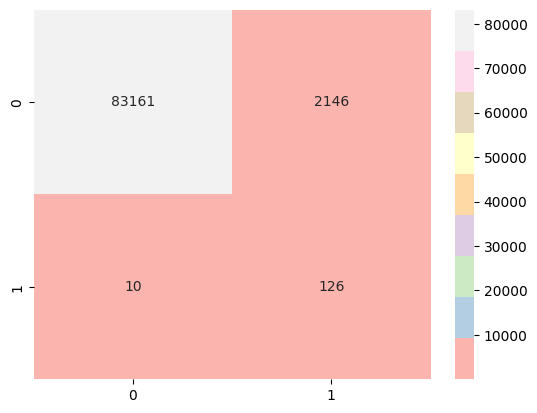

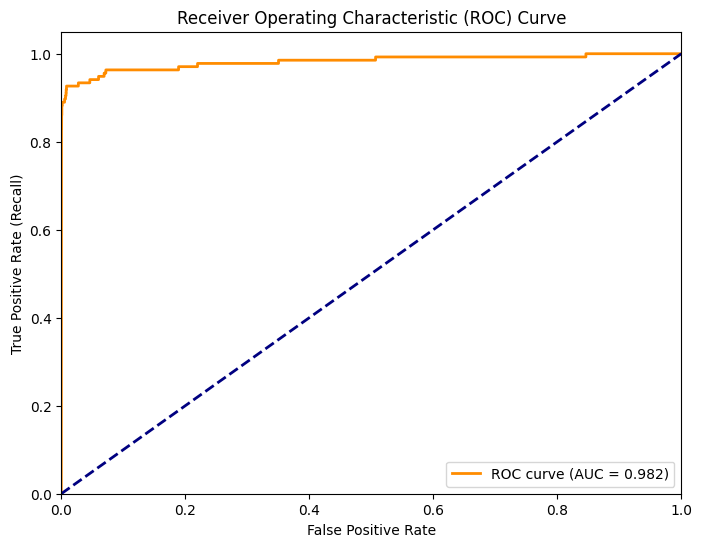

In [17]:
# Evaluating Model
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix,accuracy_score, roc_auc_score, roc_curve, auc
y_prob = model.predict_proba(X_test)[:, 1]

print("Accuracy:", accuracy_score(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Pastel1')
print(classification_report(y_test, y_pred))
print("ROC-AUC:", roc_auc_score(y_test, model.predict_proba(X_test)[:,1]))
fpr, tpr, thresholds = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

# Plot ROC curve
plt.figure(figsize=(8,6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label='ROC curve (AUC = %0.3f)' % roc_auc)
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')  # baseline
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate (Recall)')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc="lower right")
plt.show()



Random Forest Accuracy: 0.999602073897218
[[85302     5]
 [   29   107]]
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     85307
           1       0.96      0.79      0.86       136

    accuracy                           1.00     85443
   macro avg       0.98      0.89      0.93     85443
weighted avg       1.00      1.00      1.00     85443

Random Forest ROC-AUC: 0.9695483061523811


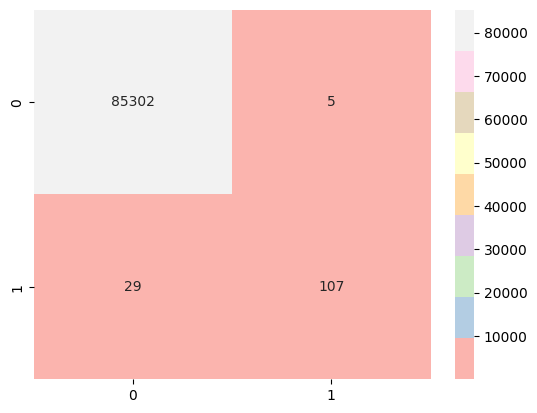

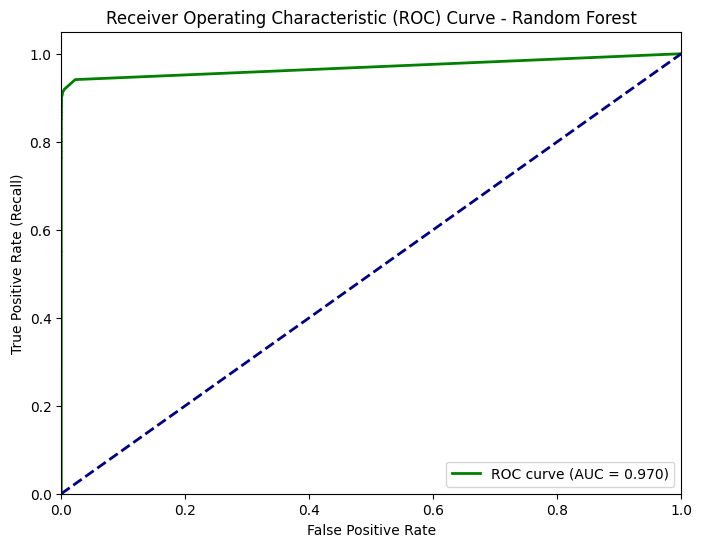

In [18]:
# Random Forest Model
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, roc_auc_score
from sklearn.ensemble import RandomForestClassifier
rf_model = RandomForestClassifier(class_weight='balanced', n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)
y_rf_pred = rf_model.predict(X_test)
y_rf_prob = rf_model.predict_proba(X_test)[:, 1]
# Evaluating Random Forest Model
print("Random Forest Accuracy:", accuracy_score(y_test, y_rf_pred))
print(confusion_matrix(y_test, y_rf_pred))
print(classification_report(y_test, y_rf_pred))
print("Random Forest ROC-AUC:", roc_auc_score(y_test, y_rf_prob))
sns.heatmap(confusion_matrix(y_test, y_rf_pred), annot=True, fmt='d', cmap='Pastel1')
plt.show()
fpr_rf, tpr_rf, thresholds_rf = roc_curve(y_test, y_rf_prob)
roc_auc_rf = auc(fpr_rf, tpr_rf)
# Plot ROC curve for Random Forest
plt.figure(figsize=(8,6))
plt.plot(fpr_rf, tpr_rf, color='green', lw=2, label='ROC curve (AUC = %0.3f)' % roc_auc_rf)
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')  # baseline
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate (Recall)')
plt.title('Receiver Operating Characteristic (ROC) Curve - Random Forest')
plt.legend(loc="lower right")
plt.show()
